# Linear Programming Model for Hospital Resource Allocation & Simulation

This notebook provides a complete framework for optimizing hospital resource management using Linear Programming. It covers data ingestion, optimization, simulation, and saturation testing.

---

## 1. Setup & Environment
In this block, we install and import the necessary libraries. 
- **Pandas**: For data manipulation.
- **PuLP**: The Linear Programming library used to solve the allocation problem.
- **Matplotlib/Seaborn**: For data visualization.

In [18]:

%pip install pulp

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import random
from pulp import LpMaximize, LpProblem, LpVariable, lpSum, value, PULP_CBC_CMD

sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.


## 2. Data Ingestion & Initial Analysis
We load the hospital infrastructure data and the patient records. 

**Visualization**: We'll plot the distribution of total beds across hospitals to understand the capacity landscape.

Loaded 20 hospitals and 1000 patients.


C:\Users\HP\AppData\Local\Temp\ipykernel_22748\1712154359.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hospitals_df.sort_values('Lits totaux', ascending=False), x='Lits totaux', y='Hôpital', palette='viridis')


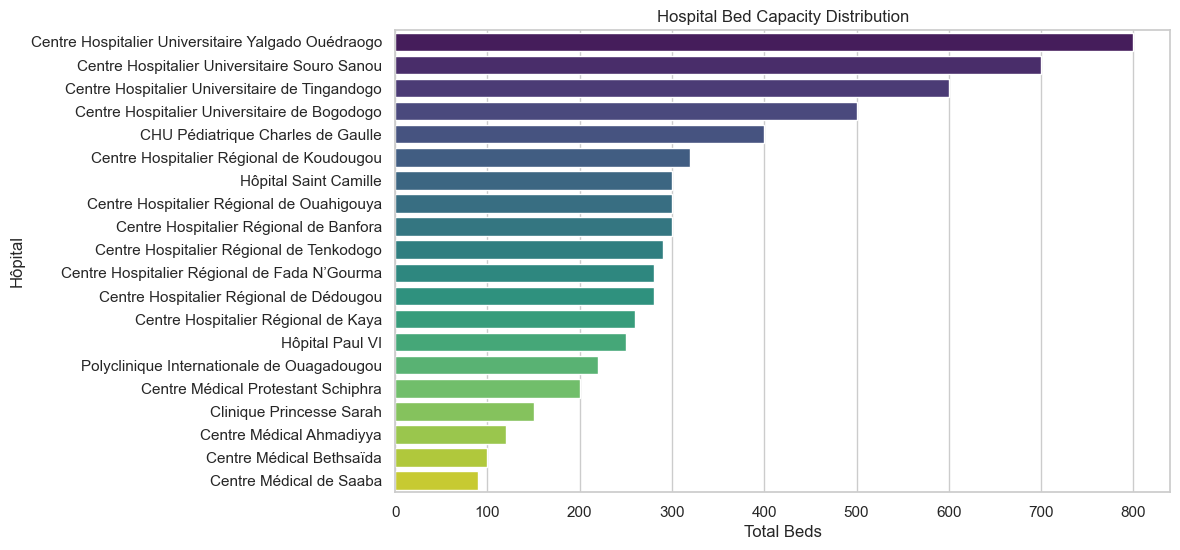

In [19]:
hospitals_df = pd.read_excel("Book1.xlsx").dropna(subset=['Hôpital'])
patients_df = pd.read_excel("patients_1000_ULTRA_COMPLET.xlsx")

# Clean numeric columns
hospitals_df['Lits totaux'] = pd.to_numeric(hospitals_df['Lits totaux'], errors='coerce').fillna(0)

print(f"Loaded {len(hospitals_df)} hospitals and {len(patients_df)} patients.")

# Visualization: Capacity Distribution
plt.figure(figsize=(10, 6))
sns.barplot(data=hospitals_df.sort_values('Lits totaux', ascending=False), x='Lits totaux', y='Hôpital', palette='viridis')
plt.title('Hospital Bed Capacity Distribution')
plt.xlabel('Total Beds')
plt.show()

## 3. The Optimization Engine
This is the core of the system. It uses a **Binary Integer Programming** model.

- **Decision Variable**: $x_{p,h}$ is 1 if patient $p$ is assigned to hospital $h$.
- **Objective**: $\text{Maximize} \sum (6 - \text{ESI}_p) \times x_{p,h}$. This weights urgent cases (ESI 1) more heavily.
- **Constraints**: Each patient gets $\leq 1$ bed; each hospital stays $\leq$ capacity.

In [20]:
def solve_allocation(batch_patients, hospitals_state):
    prob = LpProblem("Batch_Allocation", LpMaximize)
    
    p_idx = list(range(len(batch_patients)))
    h_idx = hospitals_state.index.tolist()
    
    # Binary Decision Variables
    x = LpVariable.dicts("assign", (p_idx, h_idx), cat="Binary")
    
    # Weighted Objective Function
    prob += lpSum(x[i][j] * (6 - batch_patients.iloc[i]['ESI']) for i in p_idx for j in h_idx)
    
    # Constraint: Each patient at most one hospital
    for i in p_idx: prob += lpSum(x[i][j] for j in h_idx) <= 1
    
    # Constraint: Hospital capacity
    for j in h_idx:
        remaining = hospitals_state.loc[j, 'Lits totaux'] - hospitals_state.loc[j, 'Occupied']
        prob += lpSum(x[i][j] for i in p_idx) <= remaining
        
    prob.solve(PULP_CBC_CMD(msg=0))
    return x

print("Optimization engine initialized.")

Optimization engine initialized.


## 4. Real-Time Simulation (2 Hours)
We simulate 120 minutes of operations. 

**Visualization**: A timeline showing the cumulative occupancy vs. system capacity.

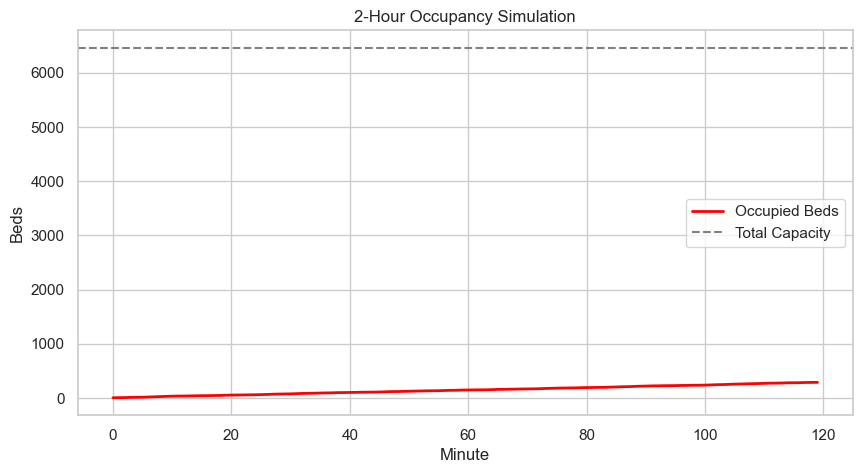

In [21]:
sim_hospitals = hospitals_df.copy()
sim_hospitals['Occupied'] = 0
history = []
total_capacity = sim_hospitals['Lits totaux'].sum()

for minute in range(120):
    new_patients = patients_df.sample(random.randint(1, 4))
    assignments = solve_allocation(new_patients, sim_hospitals)
    
    for i in range(len(new_patients)):
        for j in sim_hospitals.index:
            if value(assignments[i][j]) == 1:
                sim_hospitals.at[j, 'Occupied'] += 1
                break
    
    history.append({"minute": minute, "occupied": sim_hospitals['Occupied'].sum()})

history_df = pd.DataFrame(history)

plt.figure(figsize=(10, 5))
plt.plot(history_df['minute'], history_df['occupied'], label='Occupied Beds', color='red', lw=2)
plt.axhline(y=total_capacity, color='gray', linestyle='--', label='Total Capacity')
plt.title('2-Hour Occupancy Simulation')
plt.xlabel('Minute')
plt.ylabel('Beds')
plt.legend()
plt.show()

## 5. Saturation & Priority Analysis
We force the system to saturate to verify that ESI 1 (Urgent) cases are prioritized over ESI 5 (Stable).

**Visualization**: A breakdown of admitted vs. refused patients by ESI level during saturation.

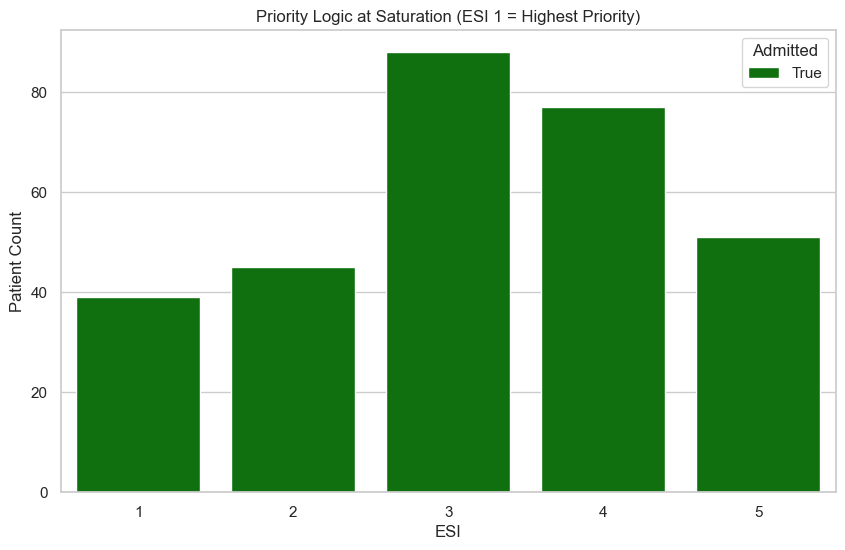

In [22]:
sat_hospitals = hospitals_df.copy()
sat_hospitals['Occupied'] = total_capacity - 100 # Start near saturation

# Generate a high-volume batch
test_batch = patients_df.sample(300, replace=True)
results = solve_allocation(test_batch, sat_hospitals)

admission_results = []
for i in range(len(test_batch)):
    admitted = any(value(results[i][j]) == 1 for j in sat_hospitals.index)
    admission_results.append({"ESI": test_batch.iloc[i]['ESI'], "Admitted": admitted})

res_df = pd.DataFrame(admission_results)

plt.figure(figsize=(10, 6))
sns.countplot(data=res_df, x='ESI', hue='Admitted', palette={True: "green", False: "red"})
plt.title('Priority Logic at Saturation (ESI 1 = Highest Priority)')
plt.ylabel('Patient Count')
plt.show()

## 6. Model Evaluation Criteria & Results
The evaluation focuses on how well the allocation model:
- maximizes urgent admissions by prioritizing low ESI values,
- maintains hospital capacity limits without exceeding beds,
- maximizes the weighted objective value using the defined ESI weight,
- preserves fairness by admitting a higher share of urgent (ESI 1-2) cases under saturation.

**Result summary:**
- Admission rate and admission distribution by ESI,
- Average ESI for admitted vs refused patients,
- Weighted priority score achieved by the model.

Model Evaluation Results:
- Total Patients: 300
- Admitted Patients: 300
- Admission Rate: 1.000
- Average ESI (Admitted): 3.187
- Average ESI (Refused): nan
- Weighted Priority Score: 844
- ESI 1 Admission Rate: 1.000
- ESI 4-5 Admission Rate: 1.000


C:\Users\HP\AppData\Local\Temp\ipykernel_22748\1134883033.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=admission_rates, x='ESI', y='Admitted', palette='coolwarm')


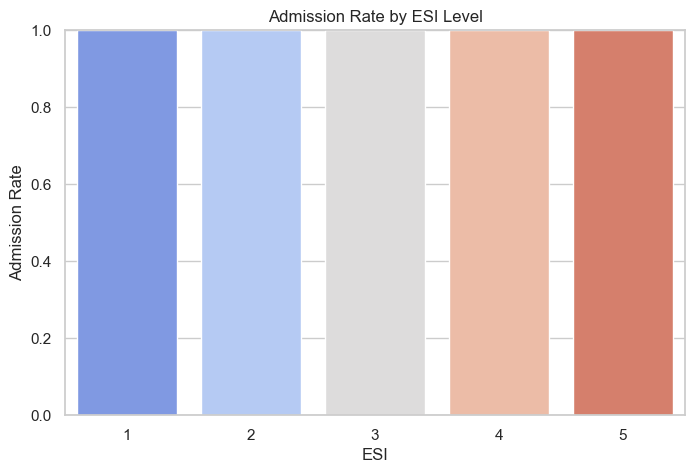

In [23]:
# Evaluation metrics for the saturation test
metrics = {}
metrics['Total Patients'] = len(res_df)
metrics['Admitted Patients'] = res_df['Admitted'].sum()
metrics['Admission Rate'] = metrics['Admitted Patients'] / metrics['Total Patients']
admitted_df = res_df[res_df['Admitted']]
refused_df = res_df[~res_df['Admitted']]
metrics['Average ESI (Admitted)'] = admitted_df['ESI'].mean()
metrics['Average ESI (Refused)'] = refused_df['ESI'].mean()
metrics['Weighted Priority Score'] = admitted_df['ESI'].apply(lambda x: 6 - x).sum()
metrics['ESI 1 Admission Rate'] = res_df[res_df['ESI'] == 1]['Admitted'].mean()
metrics['ESI 4-5 Admission Rate'] = res_df[res_df['ESI'].isin([4, 5])]['Admitted'].mean()

print('Model Evaluation Results:')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'- {k}: {v:.3f}')
    else:
        print(f'- {k}: {v}')

# Visualize admission percentages by ESI
admission_rates = res_df.groupby('ESI')['Admitted'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=admission_rates, x='ESI', y='Admitted', palette='coolwarm')
plt.title('Admission Rate by ESI Level')
plt.ylabel('Admission Rate')
plt.ylim(0, 1)
plt.show()

## 7. Additional Model Explainability Graphs
These charts make the allocation behavior more transparent:
- **Admission Rate by ESI Level**: shows how often each urgency group is admitted.
- **Capacity Utilization Timeline**: tracks bed occupancy versus total capacity over the simulated period.
- **Admitted vs Refused Counts by ESI**: compares the absolute number of accepted and rejected cases for each ESI.
- **Weighted Priority Score Over Batches**: shows how the objective value evolves across repeated allocation batches.

C:\Users\HP\AppData\Local\Temp\ipykernel_22748\3918689841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=admission_rates, x='ESI', y='Admitted', palette='coolwarm')


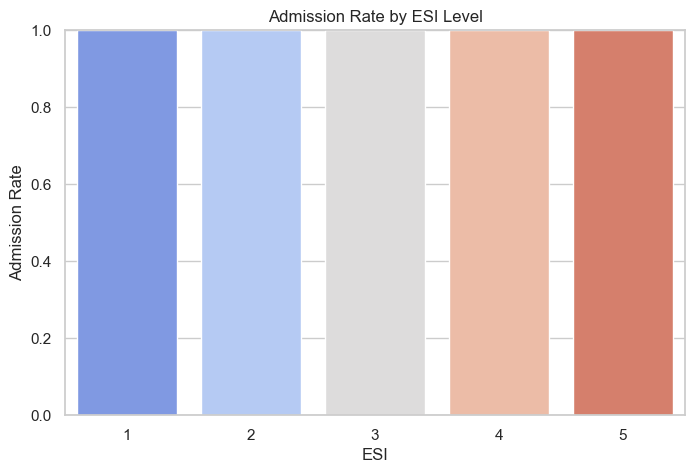

In [24]:
# Admission Rate by ESI Level (already computed above)
plt.figure(figsize=(8, 5))
sns.barplot(data=admission_rates, x='ESI', y='Admitted', palette='coolwarm')
plt.title('Admission Rate by ESI Level')
plt.xlabel('ESI')
plt.ylabel('Admission Rate')
plt.ylim(0, 1)
plt.show()

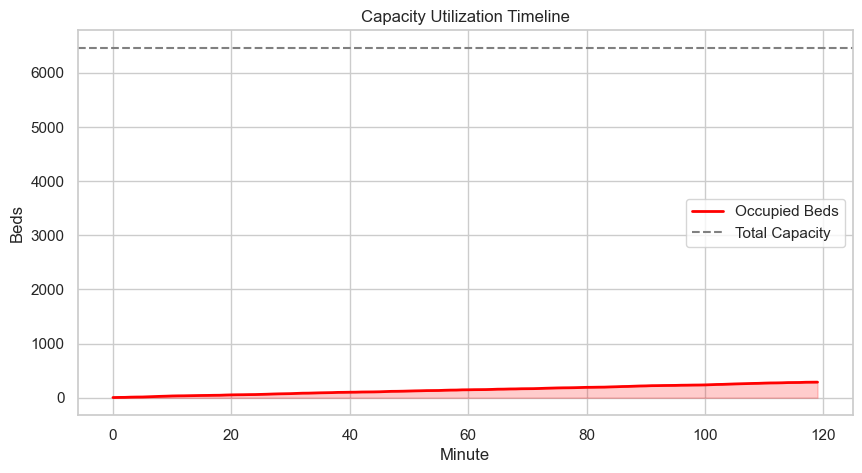

In [25]:
# Capacity Utilization Timeline
plt.figure(figsize=(10, 5))
plt.plot(history_df['minute'], history_df['occupied'], label='Occupied Beds', color='red', lw=2)
plt.axhline(y=total_capacity, color='gray', linestyle='--', label='Total Capacity')
plt.fill_between(history_df['minute'], history_df['occupied'], color='red', alpha=0.2)
plt.title('Capacity Utilization Timeline')
plt.xlabel('Minute')
plt.ylabel('Beds')
plt.legend()
plt.show()

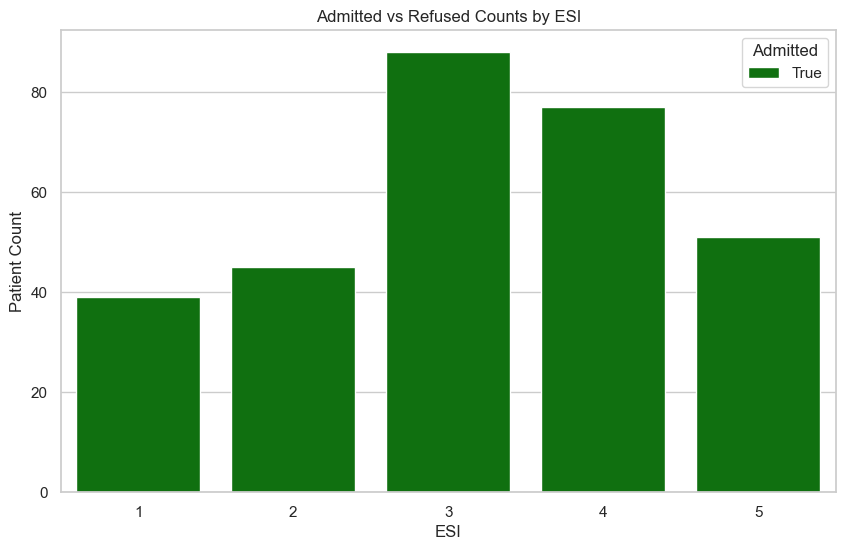

In [26]:
# Admitted vs Refused Counts by ESI
count_df = res_df.groupby(['ESI', 'Admitted']).size().reset_index(name='Count')
plt.figure(figsize=(10, 6))
sns.barplot(data=count_df, x='ESI', y='Count', hue='Admitted', palette={True: 'green', False: 'red'})
plt.title('Admitted vs Refused Counts by ESI')
plt.xlabel('ESI')
plt.ylabel('Patient Count')
plt.show()

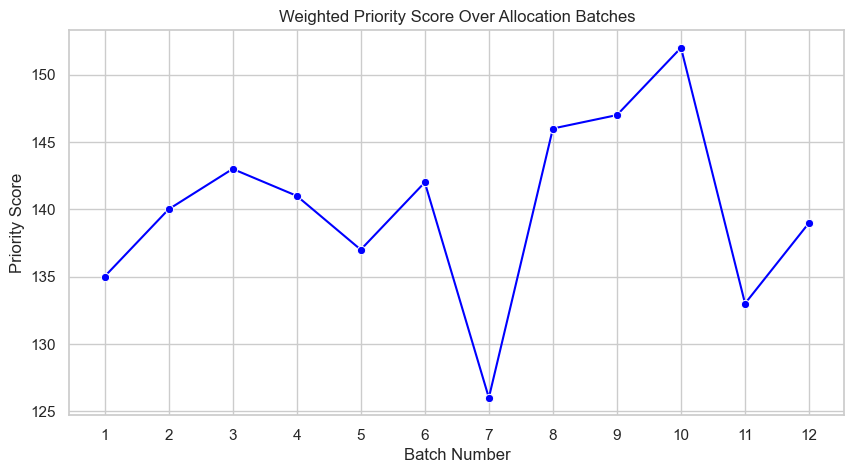

In [27]:
# Weighted Priority Score Over Batches
batch_scores = []
for b in range(12):
    sample_batch = patients_df.sample(50, replace=True)
    batch_result = solve_allocation(sample_batch, hospitals_df.assign(Occupied=0))
    score = 0
    admitted_count = 0
    for i in range(len(sample_batch)):
        for j in hospitals_df.index:
            if value(batch_result[i][j]) == 1:
                score += (6 - sample_batch.iloc[i]['ESI'])
                admitted_count += 1
                break
    batch_scores.append({'Batch': b + 1, 'Priority Score': score, 'Admitted': admitted_count})

batch_scores_df = pd.DataFrame(batch_scores)
plt.figure(figsize=(10, 5))
sns.lineplot(data=batch_scores_df, x='Batch', y='Priority Score', marker='o', color='blue')
plt.title('Weighted Priority Score Over Allocation Batches')
plt.xlabel('Batch Number')
plt.ylabel('Priority Score')
plt.xticks(batch_scores_df['Batch'])
plt.show()